# 학습 결과 비교

`infer.py --metrics-output`으로 생성한 여러 test metrics JSON 파일을 불러와 주요 지표를 표와 그래프로 비교합니다.

1. 아래 `RESULT_FILES`에 개별 파일 경로나 glob 패턴을 입력합니다.
2. 모든 셀을 순서대로 실행합니다.
3. 그래프를 파일로 남기려면 `SAVE_FIGURES = True`를 유지합니다.

In [23]:
from glob import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    if (PROJECT_ROOT.parent / "pyproject.toml").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

# 새 outputs/<experiment>/test_metrics.json 구조를 자동으로 탐색합니다.
RESULT_FILES = [
    "outputs/*/test_metrics.json",
]

# 파일명 대신 표시할 이름이 필요할 때 설정합니다.
EXPERIMENT_NAMES = {
    # "outputs/radius_005/test_metrics.json": "radius_005_baseline",
}

SAVE_FIGURES = True
FIGURE_DIR = PROJECT_ROOT / "outputs" / "experiment_comparison"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/taewoo/Downloads/모기 비행 궤적 예측 AI 경진대회


In [24]:
def expand_result_files(patterns: list[str]) -> list[Path]:
    resolved: list[Path] = []
    for pattern in patterns:
        full_pattern = Path(pattern)
        if not full_pattern.is_absolute():
            full_pattern = PROJECT_ROOT / full_pattern
        matches = [Path(match) for match in glob(str(full_pattern))]
        if not matches:
            print(f"Warning: no files matched {pattern!r}")
        resolved.extend(matches)
    return sorted(set(path.resolve() for path in resolved))


def make_experiment_name(path: Path) -> str:
    relative = path.relative_to(PROJECT_ROOT).as_posix()
    default_name = (
        path.parent.name
        if path.stem in {"valid_metrics", "test_metrics"}
        else path.stem.removeprefix("metrics_")
    )
    return EXPERIMENT_NAMES.get(relative, default_name)


def load_metric_file(path: Path) -> dict:
    with path.open(encoding="utf-8") as file:
        metrics = json.load(file)
    if not isinstance(metrics, dict):
        raise ValueError(f"Expected a JSON object: {path}")
    metrics["experiment"] = make_experiment_name(path)
    metrics["source_file"] = path.relative_to(PROJECT_ROOT).as_posix()
    return metrics


def load_experiment_results(patterns: list[str]) -> pd.DataFrame:
    paths = expand_result_files(patterns)
    if not paths:
        raise FileNotFoundError("No metric JSON files were found. Update RESULT_FILES.")
    frame = pd.DataFrame(load_metric_file(path) for path in paths)
    if frame["experiment"].duplicated().any():
        duplicates = frame.loc[frame["experiment"].duplicated(), "experiment"].tolist()
        raise ValueError(f"Duplicate experiment names: {duplicates}. Set EXPERIMENT_NAMES.")
    return frame.set_index("experiment")


results = load_experiment_results(RESULT_FILES)
print(f"Loaded {len(results)} result file(s).")

Loaded 5 result file(s).


In [25]:
SUMMARY_COLUMNS = [
    "hit_score", "mean_hit_score", "accuracy", "precision", "recall",
    "f1", "auroc", "threshold", "shots_fired", "samples", "radius", "seed",
]
available_columns = [column for column in SUMMARY_COLUMNS if column in results.columns]
summary = results.loc[:, available_columns].copy()
if {"shots_fired", "samples"}.issubset(results.columns):
    summary["fire_rate"] = results["shots_fired"] / results["samples"]

display(summary.round(4))

,hit_score,mean_hit_score,accuracy,precision,recall,f1,auroc,threshold,shots_fired,samples,radius,fire_rate
experiment,,,,,,,,,,,,
radius_001,417,0.2085,0.6810,0.8581,0.5380,0.6614,0.8096,0.77,726,2000,0.01,0.3630
radius_001_lr,369,0.1845,0.6895,0.8076,0.6088,0.6942,0.7769,0.66,873,2000,0.01,0.4365
radius_002,1300,0.6500,0.8660,0.9147,0.9307,0.9226,0.8081,0.74,1747,2000,0.02,0.8735
radius_005,1752,0.8760,0.9510,0.9671,0.9822,0.9746,0.8511,0.89,1944,2000,0.05,0.9720
radius_005_lr,1735,0.8675,0.9485,0.9613,0.9859,0.9734,0.8152,0.73,1963,2000,0.05,0.9815


Saved: outputs/experiment_comparison/mean_hit_score.png


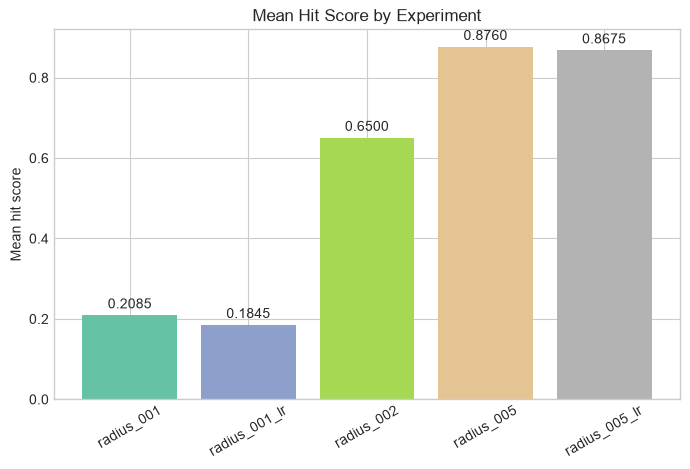

Saved: outputs/experiment_comparison/total_hit_score.png


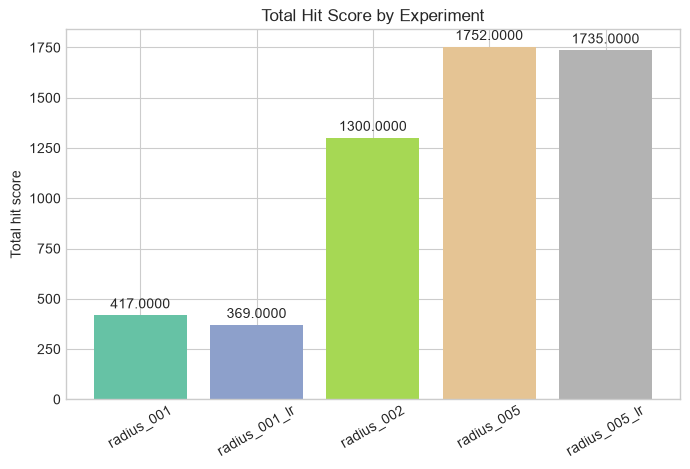

In [26]:
def save_figure(figure: plt.Figure, filename: str) -> None:
    if not SAVE_FIGURES:
        return
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    output_path = FIGURE_DIR / filename
    figure.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Saved: {output_path.relative_to(PROJECT_ROOT)}")


def plot_single_metric(metric: str, title: str, ylabel: str, filename: str) -> None:
    if metric not in summary.columns:
        print(f"Skipped missing metric: {metric}")
        return
    values = summary[metric].astype(float)
    figure, axis = plt.subplots(figsize=(max(7, len(values) * 1.2), 4.8))
    colors = plt.cm.Set2(np.linspace(0, 1, len(values)))
    bars = axis.bar(values.index, values, color=colors)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=30)
    axis.bar_label(bars, fmt="%.4f", padding=3)
    figure.tight_layout()
    save_figure(figure, filename)
    plt.show()


plot_single_metric("mean_hit_score", "Mean Hit Score by Experiment", "Mean hit score", "mean_hit_score.png")
plot_single_metric("hit_score", "Total Hit Score by Experiment", "Total hit score", "total_hit_score.png")

Saved: outputs/experiment_comparison/classification_metrics.png


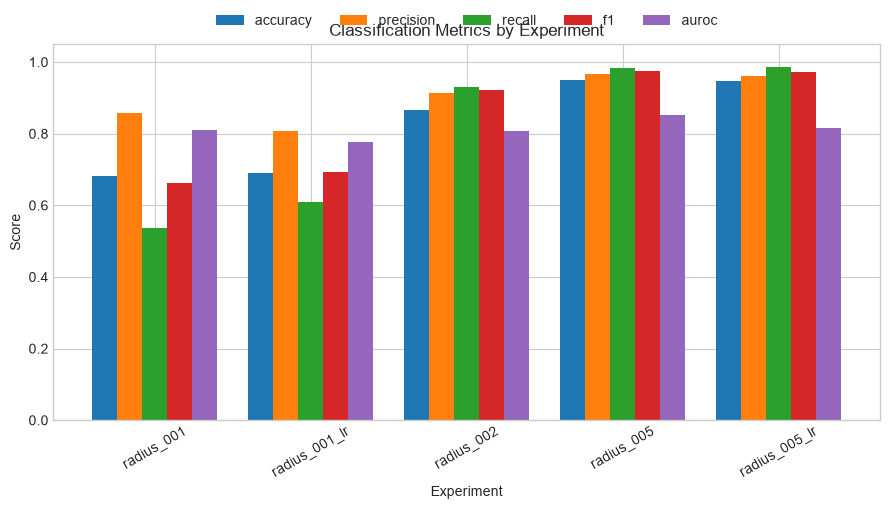

In [27]:
CLASSIFICATION_METRICS = ["accuracy", "precision", "recall", "f1", "auroc"]
available_metrics = [metric for metric in CLASSIFICATION_METRICS if metric in summary.columns]

if available_metrics:
    classification = summary[available_metrics].astype(float)
    figure, axis = plt.subplots(figsize=(max(9, len(summary) * 1.5), 5.2))
    classification.plot(kind="bar", ax=axis, width=0.8)
    axis.set_title("Classification Metrics by Experiment")
    axis.set_xlabel("Experiment")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1.05)
    axis.tick_params(axis="x", rotation=30)
    axis.legend(ncol=min(5, len(available_metrics)), loc="lower center", bbox_to_anchor=(0.5, 1.01))
    figure.tight_layout()
    save_figure(figure, "classification_metrics.png")
    plt.show()
else:
    print("No classification metrics found.")

Saved: outputs/experiment_comparison/decision_policy.png


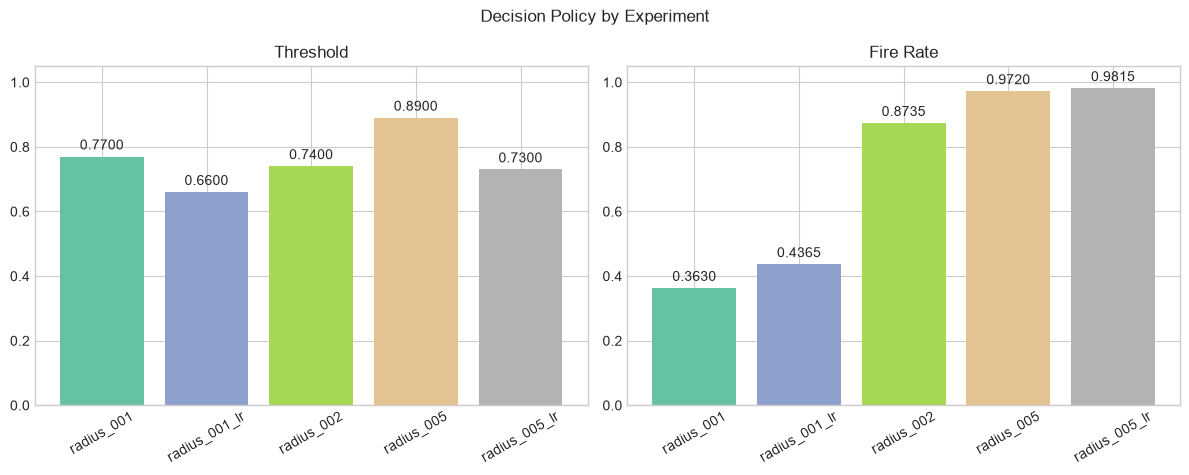

In [28]:
OPERATION_METRICS = ["threshold", "fire_rate"]
available_metrics = [metric for metric in OPERATION_METRICS if metric in summary.columns]

if available_metrics:
    operation = summary[available_metrics].astype(float)
    figure, axes = plt.subplots(1, len(available_metrics), figsize=(6 * len(available_metrics), 4.8))
    axes = np.atleast_1d(axes)
    colors = plt.cm.Set2(np.linspace(0, 1, len(operation)))
    for axis, metric in zip(axes, available_metrics, strict=True):
        bars = axis.bar(operation.index, operation[metric], color=colors)
        axis.set_title(metric.replace("_", " ").title())
        axis.set_ylim(0, 1.05)
        axis.tick_params(axis="x", rotation=30)
        axis.bar_label(bars, fmt="%.4f", padding=3)
    figure.suptitle("Decision Policy by Experiment")
    figure.tight_layout()
    save_figure(figure, "decision_policy.png")
    plt.show()
else:
    print("No decision policy metrics found.")

## 해석 기준

- **mean_hit_score**: 검증 샘플 수가 달라도 실험을 비교하기 좋은 핵심 지표입니다.
- **precision**: 발사를 결정했을 때 실제 명중하는 비율입니다.
- **recall**: 실제 명중 가능한 상황에서 발사를 선택한 비율입니다.
- **fire_rate**: 전체 샘플 중 발사를 선택한 비율입니다.
- **threshold**: 높을수록 보수적으로 발사합니다.

반경(`radius`)이나 검증 샘플 수(`samples`)가 서로 다른 결과의 총 `hit_score`는 직접 비교하지 말고 `mean_hit_score`를 우선 확인합니다.